In [1]:
import polars as pl
import numpy as np  
import sys
import pandas as pd
import funs as fn
from adjustText import adjust_text
from plotnine import *
import matplotlib.pyplot as plt
from polars import col as c
import re
theme_set(theme_minimal())

In [2]:
df = pl.read_csv("/Users/mazepeng/Desktop/DOES-MISSING-DRILLS-IN-THE-COMBINE-AFFECT-YOUR-DRAFT-/NFL_Combine_Since_2000.csv")
df["Position"].unique().to_list()

['OL',
 'DT',
 'WR',
 'SAF',
 'TE',
 'P',
 'S',
 'EDGE',
 'DL',
 'LB',
 'CB',
 'LS',
 'RB',
 'C',
 'QB',
 'DE',
 'OLB',
 'FB',
 'DB',
 'G',
 'OG',
 'CB/WR',
 'OT',
 'ILB',
 'K']

In [3]:
df = (df
 .filter(c.Position != "K")
 .filter(c.Position != "P")
 .filter(c.Position != "LS")
 )
df

First,Last,Position,School,Height,Weight,40-yd Dash,Vertical Jump,Bench Press,Broad Jump,3-Cone Drill,20-yd Shuttle,Drafted,Team,Round,Pick,Year
str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,i64
"""John""","""Abraham""","""OLB""","""South Carolina""",76,252,"""4.55""","""DNP""","""DNP""","""DNP""","""DNP""","""DNP""","""Y""","""New York Jets""","""1""","""13""",2000
"""Shaun""","""Alexander""","""RB""","""Alabama""",72,218,"""4.58""","""DNP""","""DNP""","""DNP""","""DNP""","""DNP""","""Y""","""Seattle Seahawks""","""1""","""19""",2000
"""Darnell""","""Alford""","""OT""","""Boston Col.""",76,334,"""5.56""","""25""","""23""","""94""","""8.48""","""4.98""","""Y""","""Kansas City Chiefs""","""6""","""188""",2000
"""Kyle""","""Allamon""","""TE""","""Texas Tech""",74,253,"""4.97""","""29""","""DNP""","""104""","""7.29""","""4.49""","""N""","""NA""","""NA""","""NA""",2000
"""Rashard""","""Anderson""","""CB""","""Jackson State""",74,206,"""4.55""","""34""","""DNP""","""123""","""7.18""","""4.15""","""Y""","""Carolina Panthers""","""1""","""23""",2000
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Jeremiah""","""Wright""","""G""","""Auburn""",77,331,"""DNP""","""DNP""","""DNP""","""DNP""","""DNP""","""DNP""","""Y""","""New Orleans Saints""","""4""","""132""",2026
"""Taurean""","""York""","""LB""","""Texas A&M""",71,226,"""DNP""","""DNP""","""25""","""DNP""","""7.32""","""4.48""","""N""","""NA""","""NA""","""NA""",2026
"""Colbie""","""Young""","""WR""","""Georgia""",77,218,"""4.49""","""DNP""","""DNP""","""DNP""","""DNP""","""DNP""","""Y""","""Cincinnati Bengals""","""4""","""140""",2026


In [4]:
drills = ["40-yd Dash", "3-Cone Drill", "20-yd Shuttle",
          "Vertical Jump", "Bench Press", "Broad Jump"]

summary = (df
 .with_columns(pl.col(drills).replace("DNP", None))
 .cast({d: pl.Float64 for d in drills})
 .group_by(c.Year, c.Position)
 .agg(
     n          = pl.len(),
     avg_height = c.Height.mean(),
     avg_weight = c.Weight.mean(),
     avg_40dash = c("40-yd Dash").mean(),
     avg_vert   = c("Vertical Jump").mean(),
     avg_benchp = c("Bench Press").mean(),
     avg_broadj = c("Broad Jump").mean(),
     avg_3cone  = c("3-Cone Drill").mean(),
     avg_20shut = c("20-yd Shuttle").mean(),
 )
 .sort("Year", "Position")
)
summary

Year,Position,n,avg_height,avg_weight,avg_40dash,avg_vert,avg_benchp,avg_broadj,avg_3cone,avg_20shut
i64,str,u32,f64,f64,f64,f64,f64,f64,f64,f64
2000,"""C""",4,75.25,292.5,5.1425,30.333333,21.0,103.333333,7.525,4.575
2000,"""CB""",34,70.911765,192.323529,4.519412,36.02,14.47619,119.333333,6.950435,4.147727
2000,"""DE""",21,75.47619,272.52381,4.903,32.46875,24.714286,112.25,7.441429,4.46
2000,"""DT""",27,75.0,300.518519,5.083704,29.571429,26.0,103.190476,7.608421,4.603684
2000,"""FB""",10,72.2,243.3,4.812,32.0,22.333333,112.0,7.405714,4.484286
…,…,…,…,…,…,…,…,…,…,…
2026,"""QB""",15,74.733333,219.2,4.602857,36.916667,null,122.5,7.153333,4.335
2026,"""RB""",20,70.85,208.35,4.448,36.4,20.714286,122.272727,7.32,4.4075
2026,"""SAF""",22,72.909091,200.590909,4.423571,37.09375,15.5,125.416667,null,4.31


In [5]:
long = (
    summary
    .unpivot(
        index=["Year", "Position", "n"],
        on=[c for c in summary.columns if c.startswith("avg_")],
        variable_name="metric",
        value_name="value",
    )
    .drop_nulls("value")
    .sort("metric", "Position", "Year")
)

In [6]:
import plotly.express as px

fig = px.line(
    long.to_pandas(),
    x="Year", y="value", color="Position",
    facet_col="metric", facet_col_wrap=2,
    markers=True,
    hover_data=["n"],
    height=1600,
)
fig.update_yaxes(matches=None)   # 关键：每个 facet 独立 y 轴
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()

In [7]:
px.line(
    long.filter(c.metric == "avg_40dash").to_pandas(),
    x="Year", y="value", color="Position", markers=True,
)

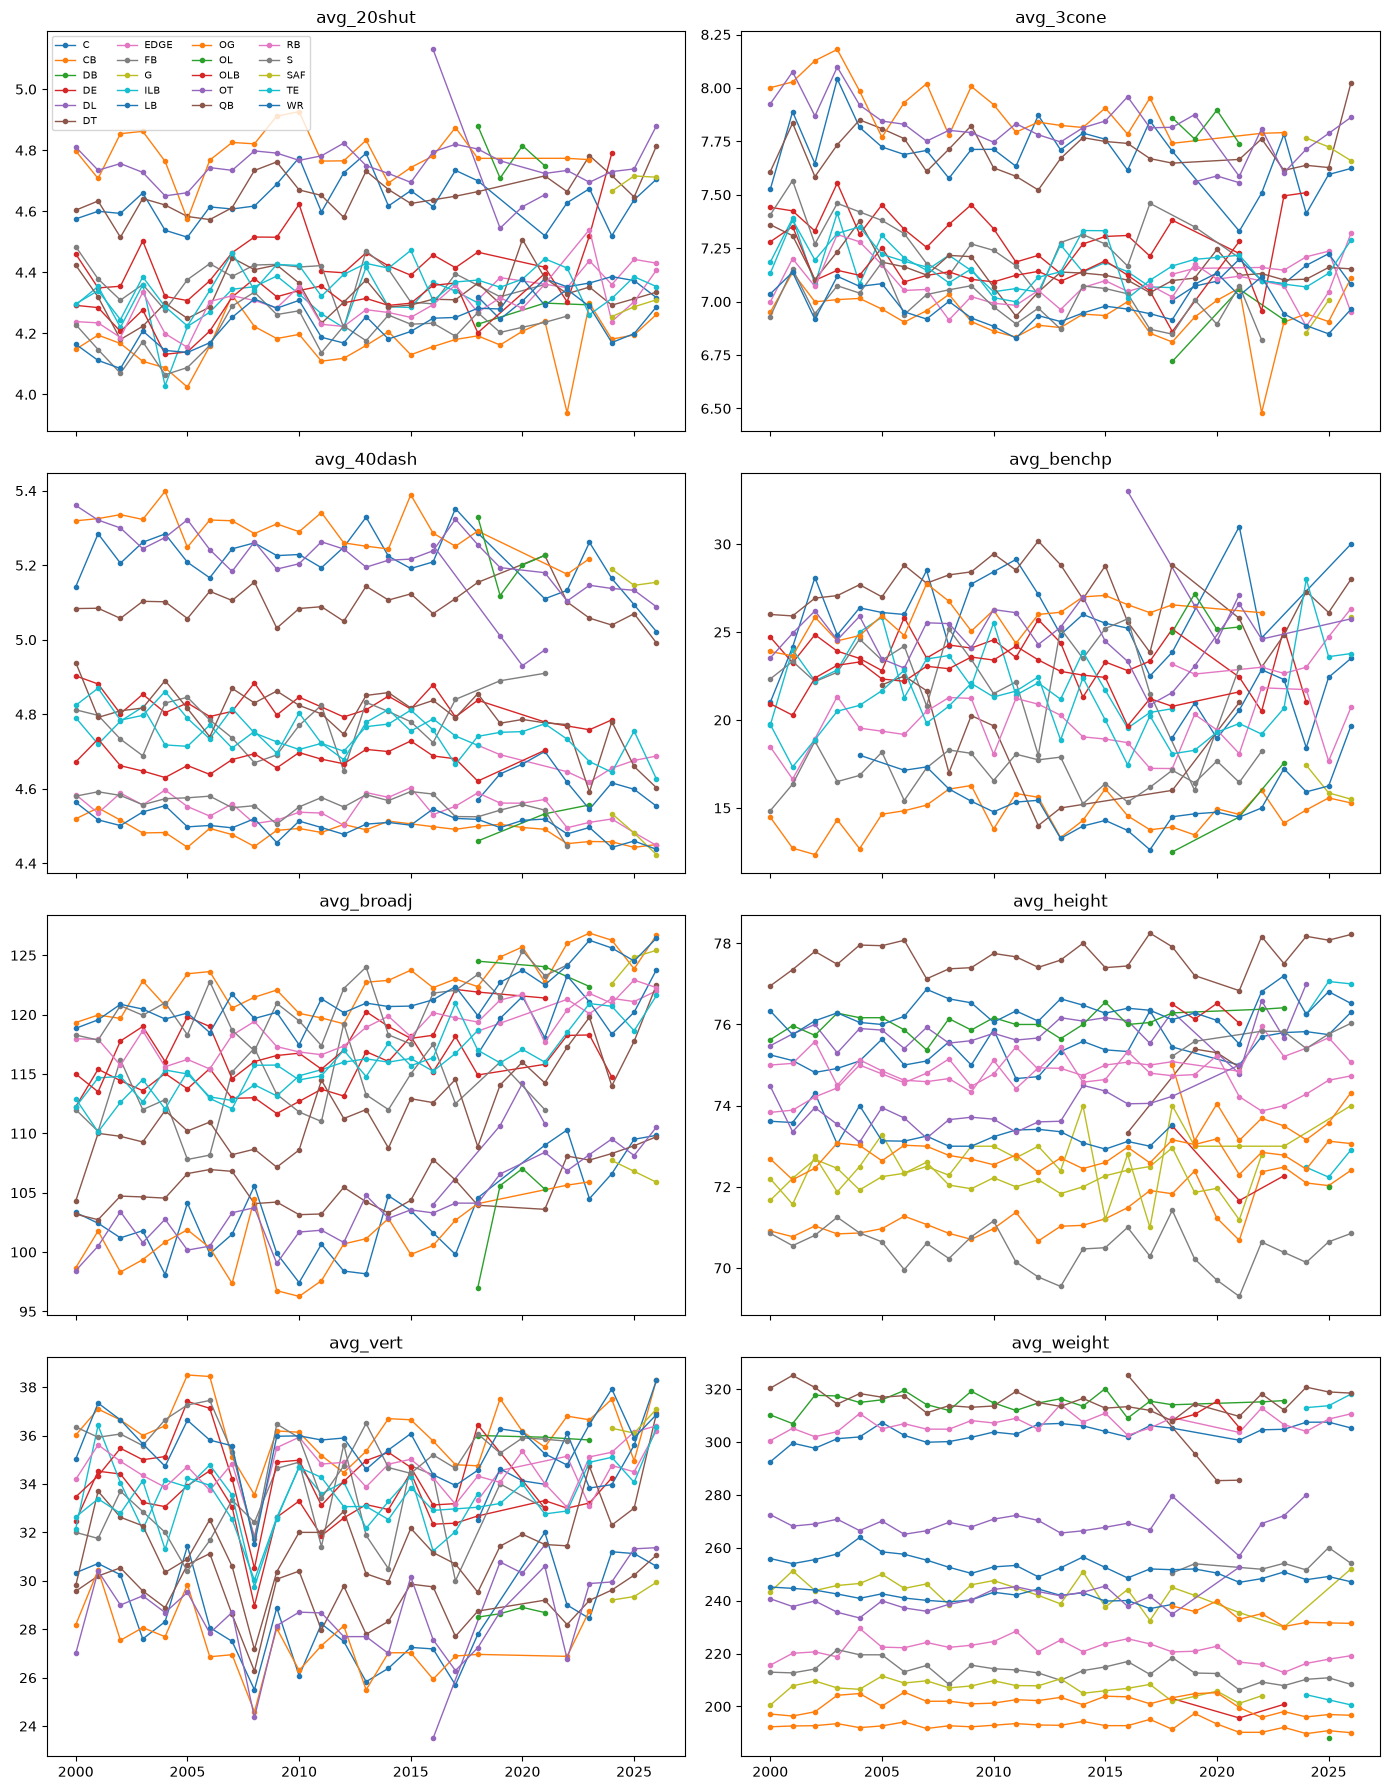

In [8]:

metrics = long["metric"].unique(maintain_order=True).to_list()
fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True)

for ax, m in zip(axes.flat, metrics):
    sub = long.filter(c.metric == m)
    for pos in sub["Position"].unique().sort():
        d = sub.filter(c.Position == pos).sort("Year")
        ax.plot(d["Year"], d["value"], marker="o", ms=3, lw=1, label=pos)
    ax.set_title(m)

axes.flat[0].legend(ncol=4, fontsize=7, loc="upper left")
plt.tight_layout()

In [9]:
POS = "TE"

fig = px.line(
    long.filter(c.Position == POS).to_pandas(),
    x="Year", y="value",
    facet_col="metric", facet_col_wrap=2,
    markers=True, hover_data=["n"], height=1400,
    facet_col_spacing=0.12, 
    title=f"{POS} — Combine averages by year",
)
fig.update_yaxes(matches=None, showticklabels=True)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.update_xaxes(showticklabels=True)

In [10]:
POS = "C"

fig = px.line(
    long.filter(c.Position == POS).to_pandas(),
    x="Year", y="value",
    facet_col="metric", facet_col_wrap=2,
    markers=True, hover_data=["n"], height=1400,
    facet_col_spacing=0.12, 
    title=f"{POS} — Combine averages by year",
)
fig.update_yaxes(matches=None, showticklabels=True)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.update_xaxes(showticklabels=True)

In [ ]:

import re
from pathlib import Path
import polars as pl
from polars import col as c
import plotly.express as px
from pypdf import PdfWriter
long_plot = (
    long
    .filter(~c.Position.str.contains("/"))  
    .filter(c.n >= 8)                      
)

positions = long_plot["Position"].unique().sort().to_list()
print(f"{len(positions)} positions: {positions}")

def plot_position(pos):
    fig = px.line(
        long_plot.filter(c.Position == pos).to_pandas(),
        x="Year", y="value",
        facet_col="metric", facet_col_wrap=2,
        markers=True, hover_data=["n"],
        height=1400, facet_col_spacing=0.12,
        title=f"{pos} — Combine averages by year",
    )
    fig.update_yaxes(matches=None, showticklabels=True, title_text="")
    fig.update_xaxes(showticklabels=True)
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
    return fig

out = Path("figs")
out.mkdir(exist_ok=True)

def safe_name(p):
    return re.sub(r"[^\w-]", "_", p)

for pos in positions:
    plot_position(pos).write_image(
        out / f"{safe_name(pos)}.pdf", width=1200, height=1400
    )
    print(f"  ✓ {pos}")

w = PdfWriter()
for pos in positions:
    w.append(str(out / f"{safe_name(pos)}.pdf"))
w.write("all_positions.pdf")
w.close()

print(f"\n → all_positions.pdf（{len(positions)} ）")

21 positions: ['C', 'CB', 'DB', 'DE', 'DL', 'DT', 'EDGE', 'FB', 'G', 'ILB', 'LB', 'OG', 'OL', 'OLB', 'OT', 'QB', 'RB', 'S', 'SAF', 'TE', 'WR']
  ✓ C
  ✓ CB
  ✓ DB
  ✓ DE
  ✓ DL
  ✓ DT
  ✓ EDGE
  ✓ FB
  ✓ G
  ✓ ILB
  ✓ LB
  ✓ OG
  ✓ OL
  ✓ OLB
  ✓ OT
  ✓ QB
  ✓ RB
  ✓ S
  ✓ SAF
  ✓ TE
  ✓ WR

完成 → all_positions.pdf（21 页）
